# Full Optimization Pipeline on HSCs.

## Prepare the notebook.

### Flags for autoreloading.

In [109]:
AUTORELOAD = True
IS_EXT_LOADED = False

### Optionally autoreload the notebook.

In [110]:
if AUTORELOAD:
    if not IS_EXT_LOADED:
        %load_ext autoreload
        IS_EXT_LOADED = True
    assert IS_EXT_LOADED
    %autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Import libraries.

In [111]:
from collections import defaultdict
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from scipy.spatial.distance import cdist
from scipy.special import softmax
from scipy.stats import gaussian_kde
from sklearn.neighbors import KernelDensity
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import torch
from tqdm import tqdm
import yaml

from labcompass.constants import DataFields, ParamsFields, PredictionFields
from labcompass.config import NeuralVelocityFieldConfig
from labcompass.metrics import compute_e_distance
from labcompass.models import FlowMatching, TargetPredictionModel
from labcompass.utils import set_reproducibility
from labcompass.training.callbacks import MetricsCallBack, TrainingCallBacks


### Define directories.

In [112]:
BASE_DIR = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC"
PERTURBATION_RESPONSE_MODEL_CHECKPOINT_PATH = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/dumps/2025-12-14_11-53-04/cerulean-durian-19_FlowMatching.pkl"
PERTURBATION_RESPONSE_MODEL_CHECKPOINT_PATH = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/dumps/2026-02-02_19-09-41/charmed-puddle-158_FlowMatching.pkl" # in distribution

TARGET_PREDICTION_MODEL_CHECKPOINT_PATH = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/dumps/2025-11-14_21-22-45/dashing-frog-1258_TargetPredictionModel.pkl"
PRIOR_FLOW_CHECKPOINT_PATH = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/prior_flow_FlowMatching.pkl"
ANNOTATION_CONFIG_PATH = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/generative_modeling/conditional_flow_matching/config/annotation/default.yaml"


### Define constants.

In [113]:
perturbation_obs_key = "protocol_id"
cell_state_rep = "X_channel_standardized+X_scatter_standardized"

RANDOM_SEED = 42

### Import additional modules.

In [114]:
sys.path.insert(0, f"{BASE_DIR}/inverse/inverse_utils")
sys.path.insert(0, f"{BASE_DIR}/model_utils")
from forward_model import ForwardModel
from lambda_schedulers import schedulers_dict
from loss_guidance import LossGuidedFlow
from z_norm_modules import ZNorm, IZNorm, RescaledTargetPredictionModel


### Read annotation config.

In [115]:
with open(ANNOTATION_CONFIG_PATH, "r") as fb:
    annotation_dict = yaml.safe_load(fb)

### Retrieve scatter features identifiers.

In [116]:
scatter_columns = annotation_dict["scatter_columns"]
n_scatter_feats = len(scatter_columns)
print(f"{n_scatter_feats=}")

n_scatter_feats=6


### Setting seed for reproducibility.

In [117]:
set_reproducibility(RANDOM_SEED)

## Load pretrained models.

### Load cellular response prediction model ($\Phi$).

We will use a pre-trained Conditional Flow Matching model to generate synthetic marker expression and morphological features under distinct medium conditions.

NeuralVelocityField(
  (vf_modules): ModuleDict(
    (x_encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=27, out_features=1024, bias=True)
          (1): ELU(alpha=1.0)
        )
        (1): Sequential(
          (0): Linear(in_features=1024, out_features=1024, bias=True)
          (1): ELU(alpha=1.0)
        )
        (2): Sequential(
          (0): Linear(in_features=1024, out_features=256, bias=True)
          (1): Identity()
        )
      )
    )
    (time_encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=512, out_features=32, bias=True)
          (1): ELU(alpha=1.0)
        )
        (1): Sequential(
          (0): Linear(in_features=32, out_features=32, bias=True)
          (1): ELU(alpha=1.0)
        )
        (2): Sequential(
          (0): Linear(in_features=32, out_features=2048, bias=True)
          (1): Identity()
        )
      )
    )
    (condition_encoder): C

(<Figure size 300x300 with 1 Axes>, <Axes: title={'center': 'loss'}>)

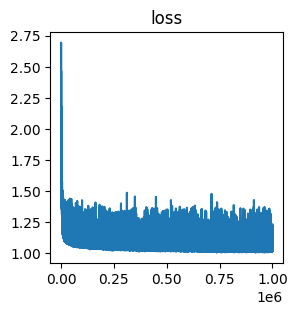

In [118]:
perturbation_response_prediction_model = FlowMatching.load(
    PERTURBATION_RESPONSE_MODEL_CHECKPOINT_PATH
)
print(f"{perturbation_response_prediction_model.velocity_field}")
perturbation_response_prediction_model.trainer.plot_training_logs()

### Load cell type prediction model ($g$).

PerturbationApproximatePosterior(
  (pert_approximate_posterior): ModuleDict(
    (encoder): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=27, out_features=2048, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.75, inplace=False)
        )
        (1): Sequential(
          (0): Linear(in_features=2048, out_features=2048, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.75, inplace=False)
        )
        (2): Sequential(
          (0): Linear(in_features=2048, out_features=2048, bias=True)
          (1): ReLU()
          (2): Dropout(p=0.75, inplace=False)
        )
        (3): Sequential(
          (0): Linear(in_features=2048, out_features=8, bias=True)
          (1): Identity()
        )
      )
    )
    (cell_type): MLPBlock(
      (net): Sequential(
        (0): Sequential(
          (0): Linear(in_features=8, out_features=19, bias=True)
          (1): Identity()
        )
      )
    )
  )
)


(<Figure size 300x300 with 1 Axes>, <Axes: title={'center': 'loss'}>)

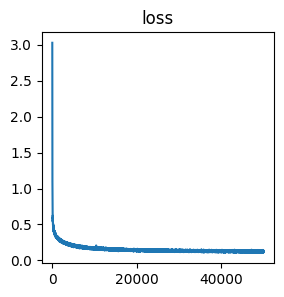

In [119]:
target_prediction_model = TargetPredictionModel.load(
    TARGET_PREDICTION_MODEL_CHECKPOINT_PATH
)
# set label encoder, we are going to need it 
ct_le = LabelEncoder().fit(target_prediction_model.train_data.adata.obs["cell_type"].values)
print(f"{target_prediction_model.target_prediction_model}")

target_prediction_model.target_predictor_trainer.plot_training_logs()

### Load prior flow model $u^\theta_t(\mathbb x, \mathbb e)$.

(<Figure size 300x300 with 1 Axes>, <Axes: title={'center': 'loss'}>)

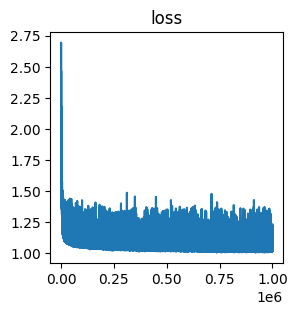

In [120]:
prior_flow = FlowMatching.load(
    PRIOR_FLOW_CHECKPOINT_PATH
)
perturbation_response_prediction_model.trainer.plot_training_logs()

## Prepare reference data.

### Retrieve data for $\Phi$ surrogate.

In [121]:
train_adata_phi = perturbation_response_prediction_model.train_data.adata
val_adata_phi = perturbation_response_prediction_model.validation_data[0].adata
print(f"{train_adata_phi=}\n{val_adata_phi=}")

train_adata_phi=AnnData object with n_obs × n_vars = 92953367 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'protocol_id'
    var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
    uns: 'meta', 'processing_steps', 'one_hot', 'gm-csf_[ng_ml]_one_hot', 'tpo_[ng_ml]_one_hot', 'sr1_[nm]_one_hot', 'um171_[nm]_one_hot', 'um729_[µm]_one_ho

### Retrieve data for $g$ model.

In [122]:
train_adata_g = target_prediction_model.train_data.adata
val_adata_g = target_prediction_model.validation_data.adata
print(f"{train_adata_g=}\n{val_adata_g=}")

train_adata_g=AnnData object with n_obs × n_vars = 70000 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'leiden', 'cell_type'
    var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
    uns: 'cell_type_colors', 'leiden', 'leiden_colors', 'meta', 'neighbors', 'processing_steps', 'umap', 'pca', 'X_scatter_params', 'X_channel_params'
   

### Subsampling data for $\Phi$ surrogate.

In [123]:
n_train_cells = 70_000
n_val_cells = 30_000
train_adata_phi = sc.pp.sample(
    train_adata_phi,
    n=n_train_cells,
    copy=True
)
val_adata_phi = sc.pp.sample(
    val_adata_phi,
    n=n_val_cells,
    copy=True
)
print(f"{train_adata_phi=}, {val_adata_phi=}")

train_adata_phi=AnnData object with n_obs × n_vars = 70000 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'protocol_id'
    var: 'n', 'channel', 'marker', '$PnD', '$PnB', '$PnR', '$PnG', '$PnE', 'signal_type', 'antibody'
    uns: 'meta', 'processing_steps', 'one_hot', 'gm-csf_[ng_ml]_one_hot', 'tpo_[ng_ml]_one_hot', 'sr1_[nm]_one_hot', 'um171_[nm]_one_hot', 'um729_[µm]_one_hot',

### Concatenate data and compute emebeddings.

In [124]:
adata_phi = sc.concat((train_adata_phi, val_adata_phi), uns_merge="same")
sc.pp.pca(adata_phi)
sc.pp.neighbors(adata_phi)
sc.tl.umap(adata_phi)
adata_phi

AnnData object with n_obs × n_vars = 100000 × 21
    obs: 'replicate', 'date', 'cytometer', 'cytometer_serial_no', 'well_id', 'count_beads', 'cell_counts', 'experiment_number', 'experiment_id', '740-yp_[µm]', 'mtg_[µm]', 'rhflt3l_[ng_ml]', 'gm-csf_[ng_ml]', 'tpo_[ng_ml]', 'sr1_[nm]', 'um171_[nm]', 'um729_[µm]', 'scf_[ng_ml]', 'butyzamide_[nm]', 'retinoic_acid_[µm]', 'ldl_[ng_ml]', 'il3_[ng_ml]', 'source_id', 'hydrogel_type', 'o2_[%]', 'source_cell_phenotype', 'total_count_beads', 'counts_source_cell_phenotype', 'days_of_culture', 'plate', 'absolute_number_multiplier_[2^n]', 'cytometer_id', 'FSC - Area', 'FSC - Height', 'FSC - Width', 'SSC - Area', 'SSC - Height', 'SSC - Width', 'Time Stamp', 'batch', 'protocol_id'
    uns: 'meta', 'processing_steps', 'one_hot', 'gm-csf_[ng_ml]_one_hot', 'tpo_[ng_ml]_one_hot', 'sr1_[nm]_one_hot', 'um171_[nm]_one_hot', 'um729_[µm]_one_hot', 'scf_[ng_ml]_one_hot', 'butyzamide_[nm]_one_hot', 'retinoic_acid_[µm]_one_hot', 'ldl_[ng_ml]_one_hot', 'il3_[ng_ml]

## Define rescaling modules.

### Small factory to instantiate rescaling modules.

In [125]:
def get_rescaling(
    adata: sc.AnnData,
    channel_params_key: str = "X_channel_params", 
    scatter_params_key: str = "X_scatter_params",
    inverse: bool = False,
) -> ZNorm | IZNorm:
    X_channel_params_fwd = adata.uns[channel_params_key]
    X_scatter_params_fwd = adata.uns[scatter_params_key]
    params = {
        ParamsFields.MEAN: torch.from_numpy(
            np.concatenate(
                (
                    X_channel_params_fwd[ParamsFields.MEAN],
                    X_scatter_params_fwd[ParamsFields.MEAN]
                ), axis=0
            )
        ),
        ParamsFields.COVARIANCE: torch.from_numpy(
            np.concatenate(
                (
                    X_channel_params_fwd["std"],
                    X_scatter_params_fwd["std"]
                ), axis=0
            )
        ),
    }
    if inverse:
        return IZNorm(params)
    return ZNorm(params)

### Get Transformations from Cellular response prediction model.

In [126]:
z_norm_phi = get_rescaling(train_adata_phi)
iz_norm_phi = get_rescaling(
    train_adata_phi,
    inverse=True
)
print(f"{z_norm_phi=}\n {iz_norm_phi=}")


z_norm_phi=ZNorm(
  (params): ModuleDict(
    (mean): ModelParam()
    (covariance): ModelParam()
  )
)
 iz_norm_phi=IZNorm(
  (params): ModuleDict(
    (mean): ModelParam()
    (covariance): ModelParam()
  )
)


### Get Transformation from Cell Type Classifier.

In [127]:
z_norm_g = get_rescaling(train_adata_g)
iz_norm_g = get_rescaling(
    train_adata_g,
    inverse=True
)
print(f"{z_norm_g=}\n {iz_norm_g=}")


z_norm_g=ZNorm(
  (params): ModuleDict(
    (mean): ModelParam()
    (covariance): ModelParam()
  )
)
 iz_norm_g=IZNorm(
  (params): ModuleDict(
    (mean): ModelParam()
    (covariance): ModelParam()
  )
)


## Forward Model.

### Initialize rescaled target prediction model.

In [128]:
g_model = RescaledTargetPredictionModel(
    target_prediction_model.target_prediction_model,
    inv_params=iz_norm_phi,
    fwd_params=z_norm_g,
)
g_model

RescaledTargetPredictionModel(
  (resc_model): ModuleDict(
    (inv_params): IZNorm(
      (params): ModuleDict(
        (mean): ModelParam()
        (covariance): ModelParam()
      )
    )
    (fwd_params): ZNorm(
      (params): ModuleDict(
        (mean): ModelParam()
        (covariance): ModelParam()
      )
    )
    (model): PerturbationApproximatePosterior(
      (pert_approximate_posterior): ModuleDict(
        (encoder): MLPBlock(
          (net): Sequential(
            (0): Sequential(
              (0): Linear(in_features=27, out_features=2048, bias=True)
              (1): ReLU()
              (2): Dropout(p=0.75, inplace=False)
            )
            (1): Sequential(
              (0): Linear(in_features=2048, out_features=2048, bias=True)
              (1): ReLU()
              (2): Dropout(p=0.75, inplace=False)
            )
            (2): Sequential(
              (0): Linear(in_features=2048, out_features=2048, bias=True)
              (1): ReLU()
            

### Initialize Forward Model.

In [129]:
forward_model = ForwardModel(
    forward_model=perturbation_response_prediction_model,
    target_prediction_model=g_model,
)
forward_model

## Predict cell type on full data.

### Forward pass on the model.

In [130]:
X_train = torch.from_numpy(train_adata_phi.obsm[cell_state_rep]).float().cuda()
X_val = torch.from_numpy(val_adata_phi.obsm[cell_state_rep]).float().cuda()

g_model.eval()
with torch.no_grad():
    G_logits_train = g_model(
        X_train
    )["cell_type"].detach().cpu().numpy()
    G_logits_val = g_model(
        X_val
    )["cell_type"].detach().cpu().numpy()

### Post process output.

In [131]:
G_probs_train = softmax(G_logits_train, axis=1)
G_probs_val = softmax(G_logits_val, axis=1)

G_id_train = G_probs_train.argmax(1)
G_id_val = G_probs_val.argmax(1)

G_label_train = ct_le.inverse_transform(G_id_train)
G_label_val = ct_le.inverse_transform(G_id_val)
print(f"{G_logits_train.shape=}, {G_logits_val.shape=}, {G_probs_train.shape=}, {G_probs_val.shape=}, {G_id_train.shape=}, {G_id_val.shape=}, {G_label_train.shape=}, {G_label_val.shape=}")


G_logits_train.shape=(70000, 19), G_logits_val.shape=(30000, 19), G_probs_train.shape=(70000, 19), G_probs_val.shape=(30000, 19), G_id_train.shape=(70000,), G_id_val.shape=(30000,), G_label_train.shape=(70000,), G_label_val.shape=(30000,)


#### Plot proportion of predicted cell types.

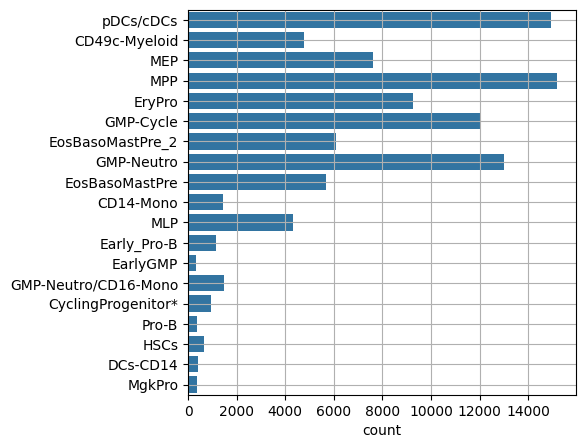

In [132]:
plt.figure(figsize=(5,5))
sns.countplot(np.concatenate((G_label_train, G_label_val), axis=0))
plt.grid(1)

## Posterior Sampling.

### Define settings.

In [133]:
solver_kwargs_forward_model = {"method": "euler"}
loss_fns = {
"cell_type": lambda pred, target:
    -torch.sum(
        target*torch.nn.functional.log_softmax(pred, dim=-1),
        dim=-1
    )
}


### Initialize guided flow.

In [134]:
n_fwd_samples = 500
reg = "l1"
reg_strength = 1e-2
n_time_steps_forward_model = 10

guided_flow = LossGuidedFlow(
    prior_flow,
    forward_model,
    loss_fns,
    fix_noise=True,
    num_forward_pass_per_sample=n_fwd_samples,
    regularization=reg,
    reg_strength=reg_strength,
    n_time_steps_forward_model=n_time_steps_forward_model,
    solver_kwargs_forward_model=solver_kwargs_forward_model
)
non_linearity = torch.nn.ReLU()

### Initialize scheduler.

In [135]:
scheduler_id = "reciprocal"
lmax = 5.0
lmin = 0.0
gamma = 5.5
scheduler = schedulers_dict[scheduler_id](lmax=lmax, lmin=lmin, gamma=gamma)
scheduler

### Visualize schedule.

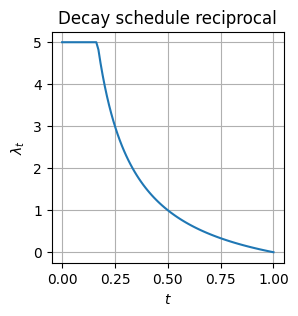

In [136]:
# visualizing decaying scheduler
t = torch.linspace(0.0, 1.0, 100)
lambda_t = scheduler.compute_lambda_t(t)
plt.figure(figsize=(3, 3))
plt.plot(t, lambda_t)
plt.title(fr"Decay schedule {scheduler_id}")
plt.xlabel(r"$t$")
plt.ylabel(r"$\lambda_t$")
plt.grid(True)

### Define Target.

In [137]:
target_cell_type = "EryPro"
classes = ct_le.classes_.tolist()
n_classes = len(classes)

idx = classes.index(target_cell_type)
target = torch.zeros((n_classes,)).float().to(forward_model.forward_model.device)
target[idx] = 1.0
target = {
    "cell_type": target.unsqueeze(0)
}
target

{'cell_type': tensor([[0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
          0.]], device='cuda:0')}

### Sampling from inverse model.

In [138]:
use_sde = False
n_samples = 150
n_time_steps = 30 if use_sde else 100
solver_kwargs = {"method": "euler"}
seed = 42
set_reproducibility(seed)

torch.cuda.empty_cache()
traj, loss_history, lambda_history, noise = guided_flow.sample_posterior(
    n_samples,
    optimal_condition=target,
    num_time_steps=n_time_steps,
    solver_kwargs=solver_kwargs,
    lambda_scheduler=scheduler,
    non_linearity=non_linearity,
    sde_sampling=use_sde
)

torch.cuda.empty_cache()
print(f"{traj.shape=}, {loss_history.shape=}, {lambda_history.shape=}, {noise.shape=}")

/home/icb/lorenzo.consoli/miniconda3/envs/sc_exp_design/lib/python3.12/site-packages/torchdiffeq/_impl/misc.py:306: UserWarning: t is not on the same device as y0. Coercing to y0.device.
  warnings.warn("t is not on the same device as y0. Coercing to y0.device.")


traj.shape=(150, 100, 12), loss_history.shape=(150, 99), lambda_history.shape=(150, 99), noise.shape=torch.Size([150, 500, 27])


## Query Forward model with samples. 

### Prepare batch dictionary.

In [139]:
samples = np.maximum(traj[:, -1, :], 0)
perturbation_reps = next(iter(perturbation_response_prediction_model.train_data.data.perturbation_covariates))
ccondition_data = torch.from_numpy(samples).float().to(perturbation_response_prediction_model.device)
ccondition_dict = {
    perturbation_reps: ccondition_data.unsqueeze(1).repeat(1, n_fwd_samples, 1),
}

batch_dict = {
    DataFields.PERTURBATION_DATA: ccondition_dict,
    DataFields.SOURCE_STATE: noise
}

### Call forward model.

In [140]:
num_time_steps = 100
cforward_out = forward_model.predict(
    batch_dict,
    return_trajectory=False,
    no_grad=True,
    num_time_steps=num_time_steps,
    solver_kwargs=solver_kwargs,
    fix_noise=True,
)

### Post-process output.

In [141]:
X_gen = cforward_out[PredictionFields.PREDICTION_DATA].detach().cpu().numpy()
gen_ct_logits = cforward_out[PredictionFields.TARGET_PREDICTION_DATA]["cell_type"].detach().cpu().numpy()

X_channel_gen = X_gen[..., :-n_scatter_feats]
X_scatter_gen = X_gen[..., -n_scatter_feats:]

gen_ct_probs = softmax(gen_ct_logits, axis=-1)
gen_ct_id_label = gen_ct_probs.argmax(-1)
gen_ct_label = ct_le.inverse_transform(gen_ct_id_label.reshape(-1)).\
    reshape(gen_ct_id_label.shape[0], gen_ct_id_label.shape[1])
print(f"{X_gen.shape=}, {X_channel_gen.shape=}, {X_scatter_gen.shape=}, {gen_ct_logits.shape=} {gen_ct_id_label.shape=}, {gen_ct_label.shape=}")


X_gen.shape=(150, 500, 27), X_channel_gen.shape=(150, 500, 21), X_scatter_gen.shape=(150, 500, 6), gen_ct_logits.shape=(150, 500, 19) gen_ct_id_label.shape=(150, 500), gen_ct_label.shape=(150, 500)


### Plot loss history.

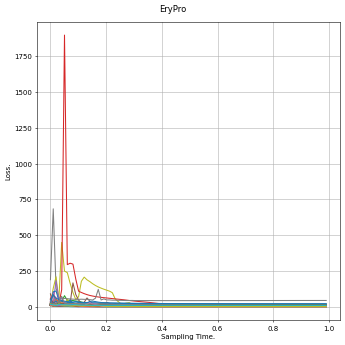

In [142]:
fig, ax = plt.subplots(figsize=(7, 7), dpi=50)
t = np.arange(0, 1, 1/loss_history.shape[1])
lines = ax.plot(t, loss_history.T)
fig.suptitle(f"{target_cell_type}")
ax.set_xlabel("Sampling Time.")
ax.set_ylabel("Loss.")
ax.grid(1)
fig.tight_layout(); fig.show()

## Visualize condition covariates.

### Displaying condition samples heatmap.

<Axes: >

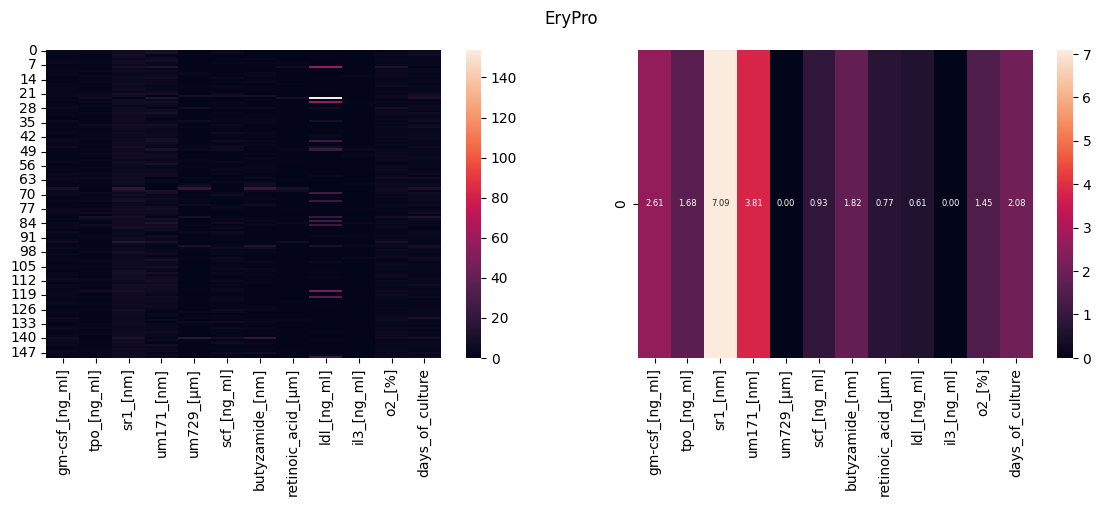

In [143]:
emin_loss_idx = np.argmin(loss_history[:, -1])
samples = np.maximum(traj[:, -1, :], 0)
fig, ax = plt.subplots(1, 2, figsize=(14, 4), dpi=100)
fig.suptitle(target_cell_type)
sns.heatmap(samples, annot=False, ax=ax[0], xticklabels=annotation_dict["protocol_columns"])
sns.heatmap(samples[emin_loss_idx][None], annot=True, ax=ax[1], xticklabels=annotation_dict["protocol_columns"], fmt=".2f", annot_kws={"size": 6})

### Hierachical cluster of the samples.

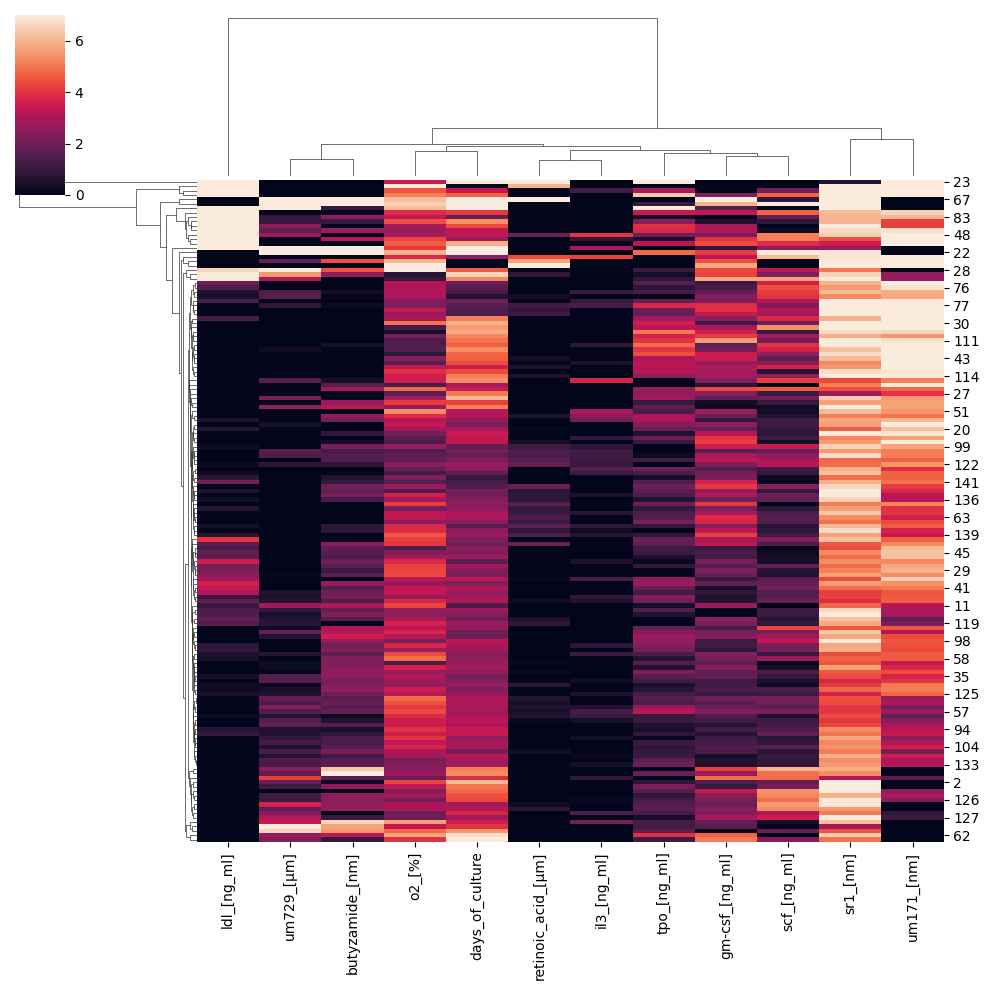

In [144]:
emin_loss_idx = np.argmin(loss_history[:, -1])
samples = np.maximum(traj[:, -1, :], 0)
sns.clustermap(samples, annot=False, xticklabels=annotation_dict["protocol_columns"], vmin=0.0, vmax=7.0)

## Visualize sampled condition in the learned embedding space.

### Retrieve learned embeddings.

In [145]:
ccond_emb = perturbation_response_prediction_model.velocity_field.get_condition_embedding(ccondition_dict)[:, 0]
ccond_emb.shape

torch.Size([150, 16])

### Sampling random projection matrices.

In [146]:
n_projections = 100000
sigma = 0.1
projections = torch.randn((n_projections, ccond_emb.shape[1], 2)).float().cuda() * sigma
print(f"{projections.shape=}")

projections.shape=torch.Size([100000, 16, 2])


### Project and average conditions.

In [147]:
projected_conds_gen = torch.einsum("nd,mdp->nmp", ccond_emb, projections).mean(1).detach().cpu().numpy()
print(f"{projected_conds_gen.shape=}")

projected_conds_gen.shape=(150, 2)


### Retrieve unique condition values from train and validation.

In [148]:
unique_train_conds = np.unique(
    train_adata_phi.obsm["condition_concat"], axis=0
)
unique_val_conds = np.unique(
    val_adata_phi.obsm["condition_concat"], axis=0
)
print(f"{unique_train_conds.shape=}, {unique_val_conds.shape=}")

unique_train_conds.shape=(115, 12), unique_val_conds.shape=(1, 12)


### Constructing condition dictionaries.

In [149]:
train_cond_dict = {
    perturbation_reps: torch.from_numpy(unique_train_conds).float().cuda()
}
val_cond_dict = {
    perturbation_reps: torch.from_numpy(unique_val_conds).float().cuda()
}

### Forward pass on condition encoder.

In [150]:
train_cond_emb = perturbation_response_prediction_model.velocity_field.get_condition_embedding(train_cond_dict)
val_cond_emb = perturbation_response_prediction_model.velocity_field.get_condition_embedding(val_cond_dict)
train_cond_emb.shape, train_cond_emb.shape

(torch.Size([115, 16]), torch.Size([115, 16]))

### Projecting real conditions.

In [151]:
projected_conds_train = torch.einsum("nd,mdp->nmp", train_cond_emb, projections).mean(1).detach().cpu().numpy()
projected_conds_val = torch.einsum("nd,mdp->nmp", val_cond_emb, projections).mean(1).detach().cpu().numpy()
print(f"{projected_conds_train.shape=}, {projected_conds_val.shape}")

projected_conds_train.shape=(115, 2), (1, 2)


### Visualize projections.

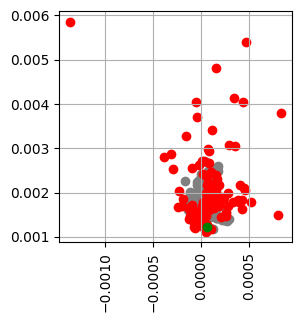

In [152]:
fig, ax = plt.subplots(figsize=(3, 3))
ax.scatter(
    projected_conds_train[:, 0],
    projected_conds_train[:, 1],
    label="train",
    color="grey",
)
ax.scatter(
    projected_conds_val[:, 0],
    projected_conds_val[:, 1],
    label="val",
    color="blue",
)
ax.scatter(
    projected_conds_gen[:, 0],
    projected_conds_gen[:, 1],
    label="val",
    color="red",
)
ax.scatter(
    projected_conds_gen[emin_loss_idx, 0][None],
    projected_conds_gen[emin_loss_idx, 1][None],
    label="val",
    color="green",
)
ax.grid(True)
ax.tick_params("x", rotation=90)

### Compute (L2) distance from real data in embedding space.

In [153]:
D_espace_learned = cdist(ccond_emb.detach().cpu().numpy(), np.concatenate((train_cond_emb.detach().cpu().numpy(), val_cond_emb.detach().cpu().numpy()), axis=0))
D_espace_learned.shape

(150, 116)

### Distribution of mean distance.

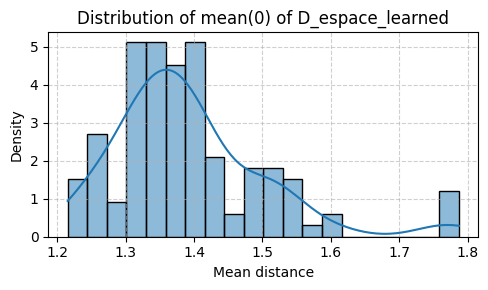

In [154]:
plt.figure(figsize=(5, 3))
sns.histplot(D_espace_learned.mean(0), bins=20, kde=True, stat="density")
plt.grid(True, linestyle="--", alpha=0.6)
plt.xlabel("Mean distance")
plt.ylabel("Density")
plt.title("Distribution of mean(0) of D_espace_learned")
plt.tight_layout()
plt.show()

### Retrieve closest neighbor in embedding space for best sample.

In [155]:
min_dist_idx = D_espace_learned[emin_loss_idx].argsort()[0].item()
nn_real_cond_best = unique_train_conds[min_dist_idx]

### Heatmap of NN condition.

<Axes: >

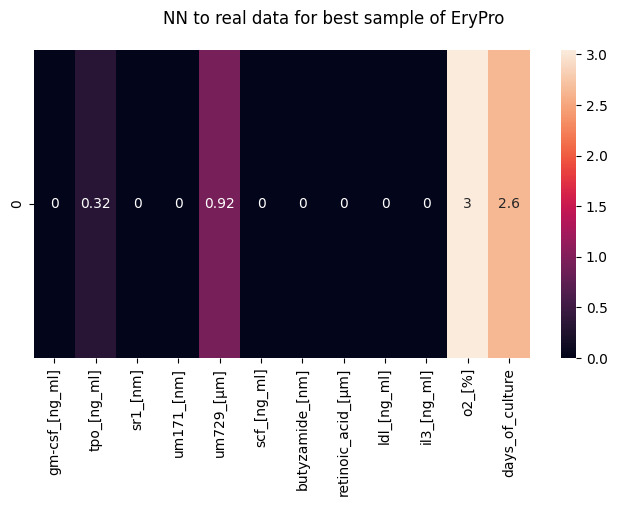

In [156]:
emin_loss_idx = np.argmin(loss_history[:, -1])
samples = np.maximum(traj[:, -1, :], 0)
fig, ax = plt.subplots(figsize=(8, 4), dpi=100)
fig.suptitle(f"NN to real data for best sample of {target_cell_type}")
sns.heatmap(nn_real_cond_best[None], annot=True, ax=ax, xticklabels=annotation_dict["protocol_columns"])

## Visualize sampled condition in the original concentration space.

### Sample random projection matrix.

In [157]:
n_projections = 100000
sigma = 0.1 
projections = torch.randn((n_projections, samples.shape[1], 2)).float().cuda() * sigma
print(f"{projections.shape=}")


projections.shape=torch.Size([100000, 12, 2])


### Project and average.

In [158]:
projected_conds_gen = torch.einsum("nd,mdp->nmp", torch.from_numpy(samples).float().cuda(), projections).mean(1).detach().cpu().numpy()
projected_conds_train = torch.einsum("nd,mdp->nmp", torch.from_numpy(unique_train_conds).float().cuda(), projections).mean(1).detach().cpu().numpy()
projected_conds_val = torch.einsum("nd,mdp->nmp", torch.from_numpy(unique_val_conds).float().cuda(), projections).mean(1).detach().cpu().numpy()
print(f"{projected_conds_train.shape=}, {projected_conds_val.shape}, {projected_conds_gen.shape=}")

projected_conds_train.shape=(115, 2), (1, 2), projected_conds_gen.shape=(150, 2)


### Visualize projections.

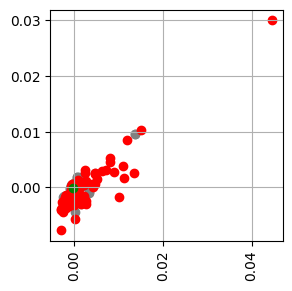

In [159]:
fig, ax = plt.subplots(figsize=(3, 3))
ax.scatter(
    projected_conds_train[:, 0],
    projected_conds_train[:, 1],
    label="train",
    color="grey",
)
ax.scatter(
    projected_conds_val[:, 0],
    projected_conds_val[:, 1],
    label="val",
    color="blue",
)
ax.scatter(
    projected_conds_gen[:, 0],
    projected_conds_gen[:, 1],
    label="val",
    color="red",
)
ax.scatter(
    projected_conds_gen[emin_loss_idx, 0][None],
    projected_conds_gen[emin_loss_idx, 1][None],
    label="val",
    color="green",
)
ax.grid(True)
ax.tick_params("x", rotation=90)

### Compute L2 distance in original concentration space.

In [160]:
D_espace_learned = cdist(samples, np.concatenate((unique_train_conds, unique_val_conds), axis=0))
D_espace_learned.shape

(150, 116)

### Plot distribution of distances.

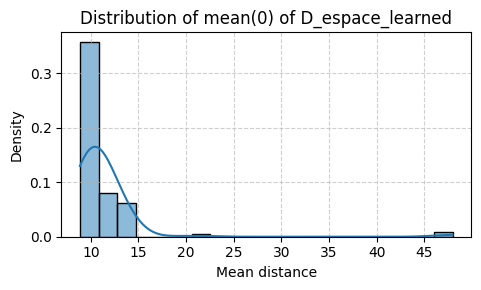

In [161]:
plt.figure(figsize=(5, 3))
sns.histplot(D_espace_learned.mean(0), bins=20, kde=True, stat="density")
plt.grid(True, linestyle="--", alpha=0.6)
plt.xlabel("Mean distance")
plt.ylabel("Density")
plt.title("Distribution of mean(0) of D_espace_learned")
plt.tight_layout()
plt.show()

### Retrieve closest neighbor in embedding space for best sample.

In [162]:
min_dist_idx = D_espace_learned[emin_loss_idx].argsort()[0].item()
nn_real_cond_best = unique_train_conds[min_dist_idx]

### Heatmap of NN condition.

<Axes: >

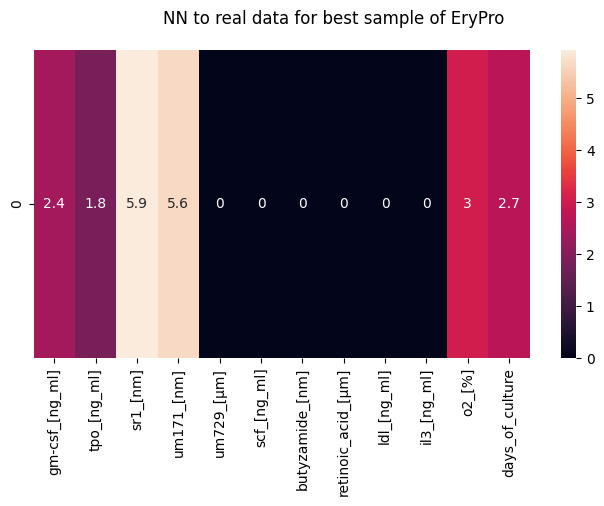

In [163]:
emin_loss_idx = np.argmin(loss_history[:, -1])
samples = np.maximum(traj[:, -1, :], 0)
fig, ax = plt.subplots(figsize=(8, 4), dpi=100)
fig.suptitle(f"NN to real data for best sample of {target_cell_type}")
sns.heatmap(nn_real_cond_best[None], annot=True, ax=ax, xticklabels=annotation_dict["protocol_columns"])

## Visualize cell type proportions.

### Displaying induced phenotype heatmap.

<Axes: >

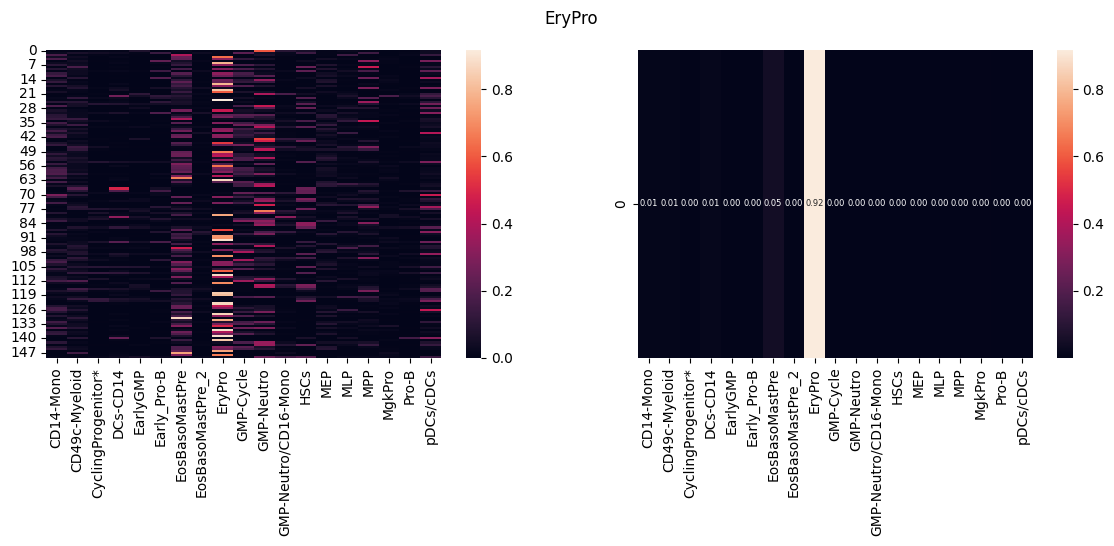

In [164]:
ct_probs = gen_ct_probs.mean(1)
samples = np.maximum(traj[:, -1, :], 0)
fig, ax = plt.subplots(1, 2, figsize=(14, 4), dpi=100)
fig.suptitle(target_cell_type)
sns.heatmap(ct_probs, annot=False, ax=ax[0], xticklabels=ct_le.classes_)
sns.heatmap(ct_probs[emin_loss_idx][None], annot=True, ax=ax[1], xticklabels=ct_le.classes_, fmt=".2f", annot_kws={"size": 6})

## Visualize generated cell states.

### Concatenate real and generated data.

In [165]:
# concatenate real and generated cell states.
X = np.concatenate(
    (
        X_gen[emin_loss_idx],
        train_adata_phi.obsm[cell_state_rep],
        val_adata_phi.obsm[cell_state_rep]
    ),
    axis=0
)
X_channel = X[:, :-n_scatter_feats]
X_scatter = X[:, -n_scatter_feats:]

# concatenate predicted cell types for real and generated data
G = np.concatenate(
    (
        gen_ct_label[emin_loss_idx],
        G_label_train,
        G_label_val,
    ),
    axis=0
)
print(f"{X_channel.shape=}, {X_scatter.shape=}{G.shape}")

X_channel.shape=(100500, 21), X_scatter.shape=(100500, 6)(100500,)


### Create annotated data.

In [166]:
ct_adata = sc.AnnData(
    X=X_channel,
    obsm={"X_scatter": X_scatter},
    obs={
        "cell_type": G,
        "data_type": ["gen"]*X_gen[emin_loss_idx].shape[0] + \
            ["train"]*len(train_adata_phi) + ["val"]*len(val_adata_phi)
    },
    var=pd.DataFrame(index=train_adata_phi.var_names)
)
sc.pp.pca(ct_adata)
sc.pp.neighbors(ct_adata)
sc.tl.umap(ct_adata)
print(f"{ct_adata=}")


ct_adata=AnnData object with n_obs × n_vars = 100500 × 21
    obs: 'cell_type', 'data_type'
    uns: 'pca', 'neighbors', 'umap'
    obsm: 'X_scatter', 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'


### Visualize UMAP embeddings.

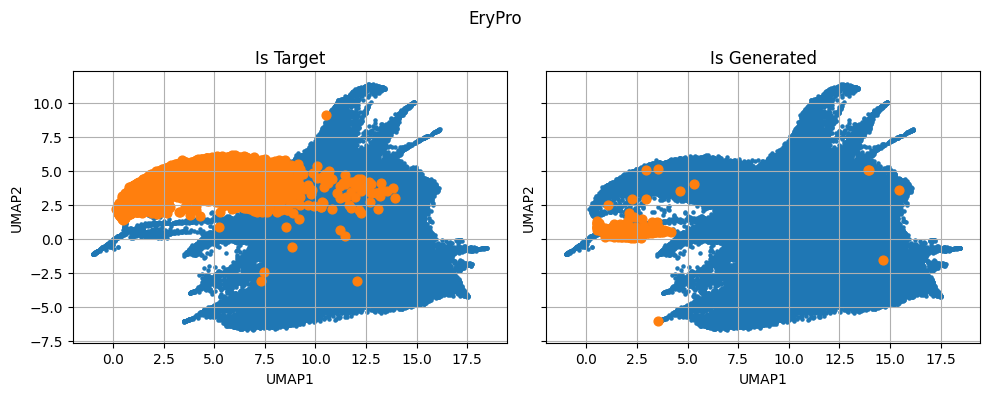

In [167]:
X_umap = ct_adata.obsm["X_umap"]
ct_mask = (ct_adata.obs["cell_type"] == target_cell_type) & (ct_adata.obs["data_type"] != "gen")
gen_mask = ct_adata.obs["data_type"] == "gen"
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
fig.suptitle(target_cell_type)
axes[0].scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    s=5,
    # alpha=0.2
)
axes[0].scatter(
    X_umap[ct_mask, 0],
    X_umap[ct_mask, 1],
    s=40,
    # alpha=0.9
)
axes[0].set_title(f"Is Target")
axes[0].grid(1)

axes[1].scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    s=5,
    # alpha=0.2
)
axes[1].scatter(
    X_umap[gen_mask, 0],
    X_umap[gen_mask, 1],
    s=40,
    # alpha=0.9
)
axes[1].set_title("Is Generated")
axes[1].grid(1)

for ax in axes:
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")

plt.tight_layout()
plt.show()

### Visualizing expression of (all) generated cells vs real HSCs.

/home/icb/lorenzo.consoli/miniconda3/envs/sc_exp_design/lib/python3.12/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/icb/lorenzo.consoli/miniconda3/envs/sc_exp_design/lib/python3.12/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/icb/lorenzo.consoli/miniconda3/envs/sc_exp_design/lib/python3.12/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/icb/lorenzo.consoli/miniconda3/envs/sc_exp_design/lib/python3.12/site-packages/anndata/_core/anndata.py:1138: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


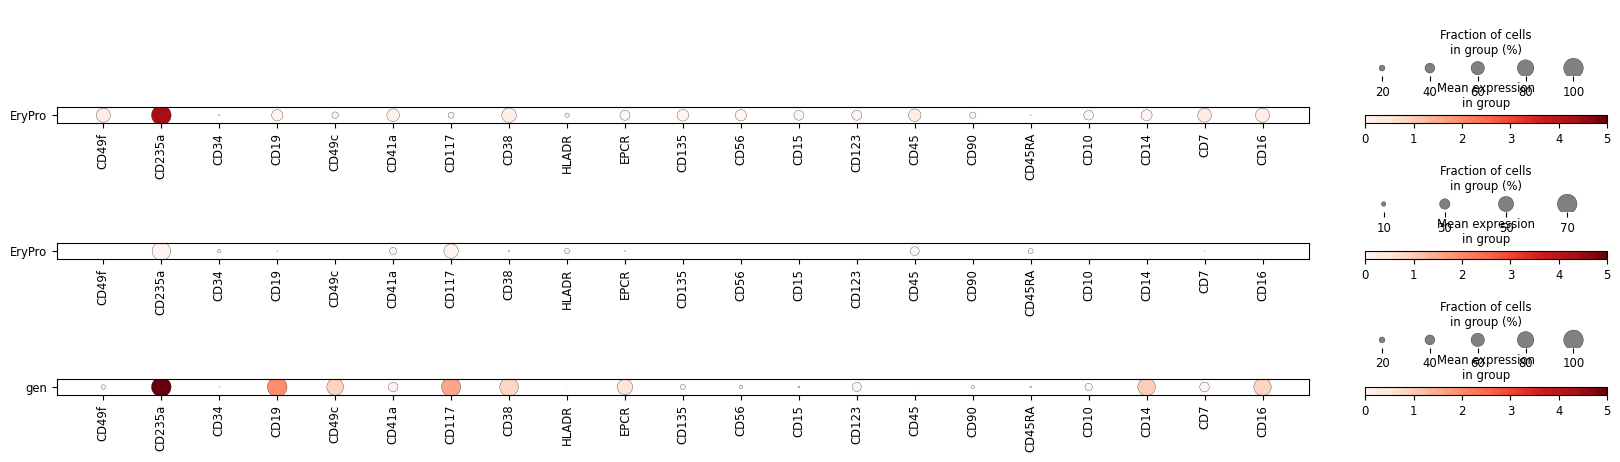

In [168]:
fig, ax = plt.subplots(3, 1, figsize=(20, 5))
vmin = 0; vmax = 5.0
sc.pl.dotplot(ct_adata[(ct_adata.obs.data_type != "gen") & (ct_adata.obs.cell_type == target_cell_type)], ct_adata.var_names, "cell_type", ax=ax[0], show=False, vmin=vmin, vmax=vmax)
sc.pl.dotplot(train_adata_g[(train_adata_g.obs.cell_type == target_cell_type)], train_adata_g.var_names, "cell_type", ax=ax[1], show=False, vmin=vmin, vmax=vmax)
sc.pl.dotplot(ct_adata[(ct_adata.obs.data_type == "gen")], ct_adata.var_names, "data_type", ax=ax[2], show=False, vmin=vmin, vmax=vmax)
fig.show()


## Population Distances.

### Computing e-dist between generated samples and cell type subpopulations (Channel Features).

In [169]:
edist_dict = defaultdict(list)
x_best = X_channel_gen[emin_loss_idx]
for ct in tqdm(classes):
    x_ct = train_adata_g[train_adata_g.obs.cell_type == ct].obsm["X_channel_standardized"]
    edist = compute_e_distance(x_best, x_ct)
    edist_dict["ct"].append(ct)
    edist_dict["edist"].append(edist)
edist_channel_df = pd.DataFrame(edist_dict).sort_values("edist", axis=0, ascending=False)
edist_channel_df

100%|██████████| 19/19 [00:04<00:00,  4.03it/s]


,ct,edist
16,MgkPro,791.682979
3,DCs-CD14,560.037528
5,Early_Pro-B,410.376346
11,GMP-Neutro/CD16-Mono,318.979492
12,HSCs,278.338922
17,Pro-B,260.304956
2,CyclingProgenitor*,249.702487
18,pDCs/cDCs,216.775111
4,EarlyGMP,215.620633
15,MPP,202.763627


### Plotting values.

/tmp/ipykernel_586088/2579984711.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


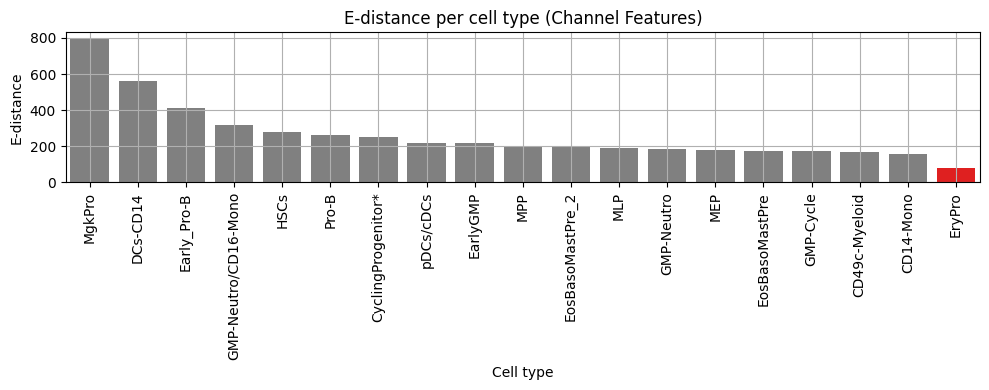

In [170]:
# Create a color column
edist_channel_df["color"] = edist_channel_df["ct"].apply(
    lambda x: "red" if x == target_cell_type else "gray"
)

plt.figure(figsize=(10, 4))
sns.barplot(
    data=edist_channel_df,
    x="ct",
    y="edist",
    palette=edist_channel_df["color"].tolist()
)

plt.grid(True)
plt.xticks(rotation=90)
plt.ylabel("E-distance")
plt.xlabel("Cell type")
plt.title("E-distance per cell type (Channel Features)")
plt.tight_layout()
plt.show()


### Computing e-dist between generated samples and cell type subpopulations (Scatter Features).

In [171]:
edist_dict = defaultdict(list)
x_best = X_scatter_gen[emin_loss_idx]
for ct in tqdm(classes):
    x_ct = train_adata_g[train_adata_g.obs.cell_type == ct].obsm["X_scatter_standardized"]
    edist = compute_e_distance(x_best, x_ct)
    edist_dict["ct"].append(ct)
    edist_dict["edist"].append(edist)
edist_scatter_df = pd.DataFrame(edist_dict).sort_values("edist", axis=0, ascending=False)
edist_scatter_df

100%|██████████| 19/19 [00:03<00:00,  5.38it/s]


,ct,edist
3,DCs-CD14,105.808866
5,Early_Pro-B,76.641762
0,CD14-Mono,62.384877
11,GMP-Neutro/CD16-Mono,43.510154
1,CD49c-Myeloid,38.440903
16,MgkPro,34.477356
10,GMP-Neutro,33.979321
2,CyclingProgenitor*,30.779591
18,pDCs/cDCs,25.018212
9,GMP-Cycle,24.073408


### Plotting values.

/tmp/ipykernel_586088/718491340.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


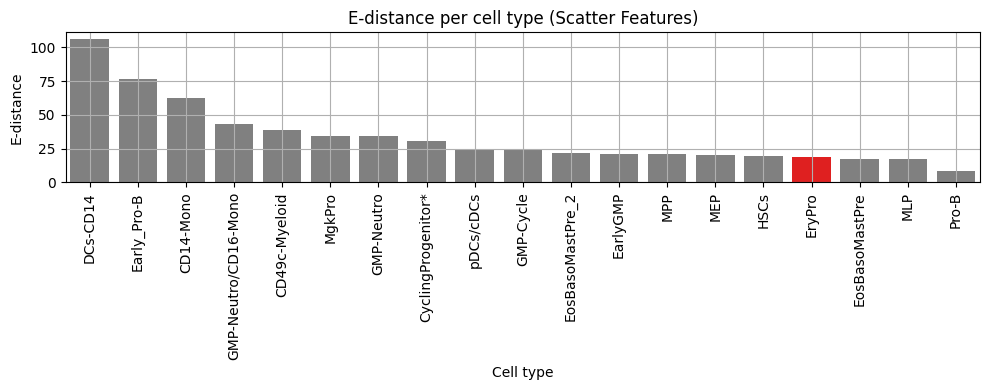

In [172]:
# Create a color column
edist_scatter_df["color"] = edist_scatter_df["ct"].apply(
    lambda x: "red" if x == target_cell_type else "gray"
)

plt.figure(figsize=(10, 4))
sns.barplot(
    data=edist_scatter_df,
    x="ct",
    y="edist",
    palette=edist_scatter_df["color"].tolist()
)

plt.grid(True)
plt.xticks(rotation=90)
plt.ylabel("E-distance")
plt.xlabel("Cell type")
plt.title("E-distance per cell type (Scatter Features)")
plt.tight_layout()
plt.show()


### Plotting cell states induced by nn condition to best sample.

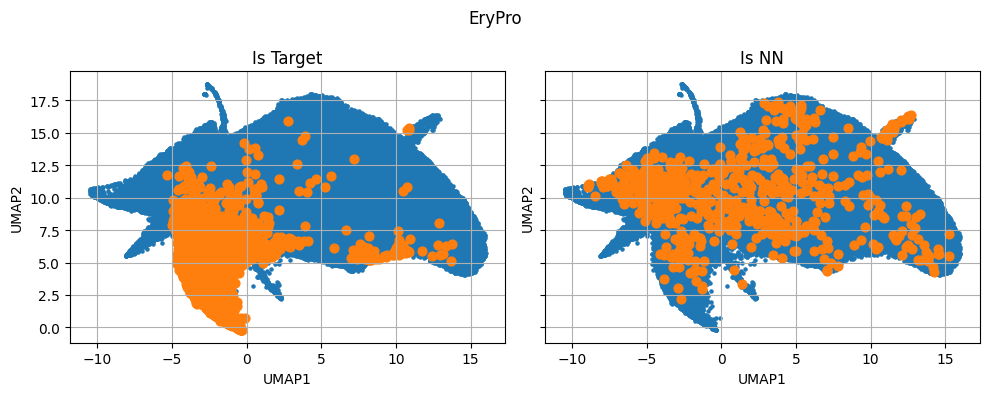

In [173]:
adata_phi.obs["cell_type"] = np.concatenate(
    (
        G_label_train,
        G_label_val,
    ),
    axis=0
)
X_umap = adata_phi.obsm["X_umap"]
ct_mask = (adata_phi.obs["cell_type"] == target_cell_type)
nn_mask = np.all(adata_phi.obsm["condition_concat"] == nn_real_cond_best, axis=1)
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)
fig.suptitle(target_cell_type)
axes[0].scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    s=5,
    # alpha=0.2
)
axes[0].scatter(
    X_umap[ct_mask, 0],
    X_umap[ct_mask, 1],
    s=40,
    # alpha=0.9
)
axes[0].set_title(f"Is Target")
axes[0].grid(1)

axes[1].scatter(
    X_umap[:, 0],
    X_umap[:, 1],
    s=5,
    # alpha=0.2
)
axes[1].scatter(
    X_umap[nn_mask, 0],
    X_umap[nn_mask, 1],
    s=40,
    # alpha=0.9
)
axes[1].set_title("Is NN")
axes[1].grid(1)

for ax in axes:
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")

plt.tight_layout()
plt.show()

## Comparing predictions with real conditions with the highest HSCs proportion.

### Iterate over the unique conditions and retrieve cell type proportions.

In [174]:
ct_counts_dict = {}
unique_conds =  np.concatenate((unique_train_conds, unique_val_conds))
for idx, cond in enumerate(unique_conds):
    cond_mask = np.all(adata_phi.obsm["condition_concat"] == cond, axis=1)
    cond_adata = adata_phi[cond_mask]
    counts = (cond_adata.obs.cell_type).value_counts().to_dict()
    ct_counts_dict[idx] = counts
ct_counts_df = pd.DataFrame(ct_counts_dict).T.fillna(0)
ct_counts_df = ct_counts_df/np.sum(ct_counts_df.values, axis=1, keepdims=True)
ct_counts_df.head()

,MPP,HSCs,CD49c-Myeloid,GMP-Cycle,pDCs/cDCs,EosBasoMastPre_2,DCs-CD14,EosBasoMastPre,Early_Pro-B,GMP-Neutro,MEP,CyclingProgenitor*,EryPro,MgkPro,MLP,GMP-Neutro/CD16-Mono,Pro-B,CD14-Mono,EarlyGMP
0,0.643836,0.109589,0.068493,0.068493,0.068493,0.013699,0.013699,0.013699,0.000000,0.000000,0.000000,0.0,0.0000,0.000000,0.00000,0.000000,0.0,0.0,0.0
1,0.609756,0.085366,0.000000,0.048780,0.134146,0.024390,0.000000,0.024390,0.036585,0.024390,0.012195,0.0,0.0000,0.000000,0.00000,0.000000,0.0,0.0,0.0
2,0.400000,0.000000,0.000000,0.400000,0.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.1,0.0000,0.000000,0.00000,0.000000,0.0,0.0,0.0
3,0.250000,0.000000,0.166667,0.250000,0.000000,0.000000,0.000000,0.000000,0.000000,0.166667,0.166667,0.0,0.0000,0.000000,0.00000,0.000000,0.0,0.0,0.0
4,0.192708,0.005208,0.000000,0.026042,0.250000,0.041667,0.000000,0.234375,0.020833,0.036458,0.041667,0.0,0.0625,0.046875,0.03125,0.010417,0.0,0.0,0.0


### Boxplot of the proportions.

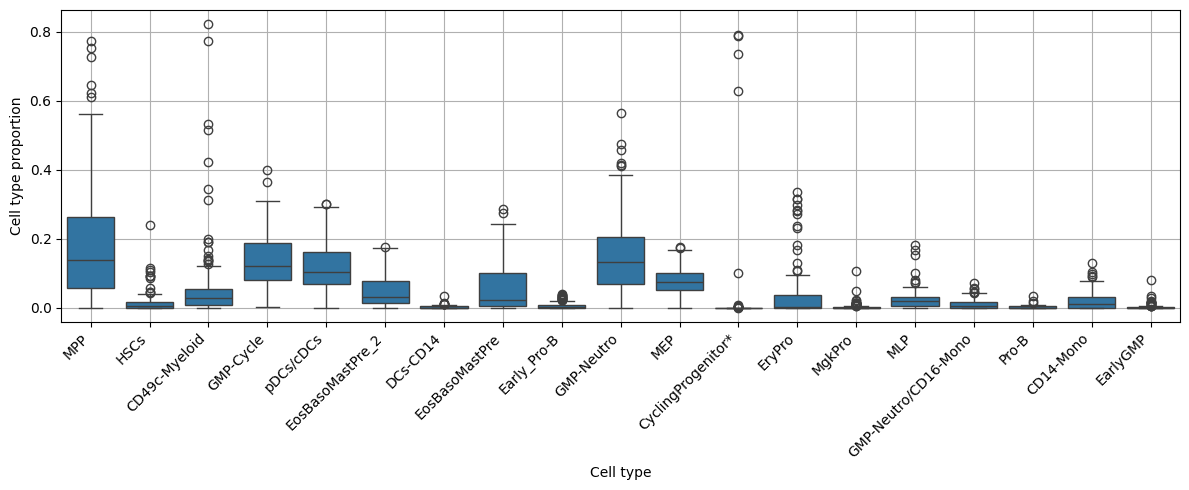

In [175]:
ct_long = ct_counts_df.reset_index(drop=True).melt(
    var_name="cell_type",
    value_name="proportion"
)

plt.figure(figsize=(12, 5))
sns.boxplot(
    data=ct_long,
    x="cell_type",
    y="proportion"
)

plt.xticks(rotation=45, ha="right")
plt.ylabel("Cell type proportion")
plt.xlabel("Cell type")
plt.tight_layout()
plt.grid(1)
plt.show()


### Retrieving conditioning inducing highest proportion of cell types.

<Axes: >

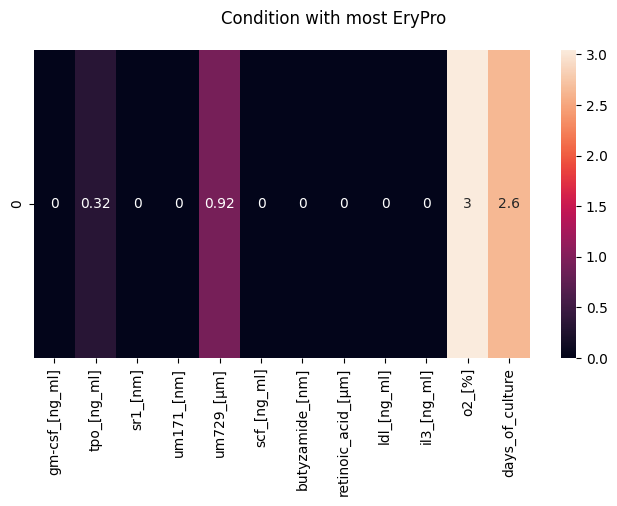

In [176]:
cond_hsc_max = unique_conds[np.argmax(ct_counts_df.loc[:, "HSCs"])][None]
fig, ax = plt.subplots(figsize=(8, 4), dpi=100)
fig.suptitle(f"Condition with most {target_cell_type}")
sns.heatmap(cond_hsc_max, annot=True, ax=ax, xticklabels=annotation_dict["protocol_columns"])